# Thermal Simulator Development

## Objective
Develop a first-order thermal simulator of the building using parameters derived from empirical observations.

The simulator aims to reproduce indoor temperature dynamics based on:
- outdoor temperature
- estimated thermal loss behavior

## Target
The target is to implement a first usable digital twin, to be used later in control application, predictions etc.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

In [2]:
# Load sample data
DATA_PATH = "../data/sample/PreliminaryAnalysis.csv"
df_raw = pd.read_csv(DATA_PATH)

In [3]:
# Import dataset from csv 
min_date = pd.to_datetime('2026-02-25 00:00:00')
max_date = pd.to_datetime('2026-03-02 23:00:00')
df_raw['time'] = pd.to_datetime(df_raw['time'])
df_filtered = df_raw.loc[(df_raw['time'] >= min_date) & (df_raw['time'] <= max_date)]
df_filtered = df_filtered.set_index("time")
print(df_filtered.index.min(), df_filtered.index.max())

2026-02-25 00:00:00 2026-03-02 23:00:00


## Results on Estimated Cooling Rate based on First Order Model

**Living Room**
- Mean: 
    - k = 0.01150 1/h
    - τ = 88.9 h
    - ΔT ≈ 9°C
    - dT/dt ≈ -0.104 °C/h

**Bedroom**
- Mean: 
    - k = 0.01027 1/h
    - τ = 100.5 h
    - ΔT ≈ 9.4°C
    - dT/dt ≈ -0.097 °C/h

In [4]:
# Parameters definition
column_in = "temp_salon_c"
column_out = "temp_out_1_b_c"
k = 0.011497 # as found in parameters_indentification
dt = 1.0 # hours

# Initial Time window selection
df_sim = df_filtered.loc[min_date:max_date, [column_in, column_out]].dropna().copy()

## Thermal Simulator v1
$T_{t+1} = T_t + (-k (T_t - T_{out})) \Delta T$

In [5]:
def simulate_first_order(T0, Tout_series, k, dt=1.0):
    """
    T_{t+1} = T_t + (-k * (T_t - T_out)) * dt
    """
    Tsim = np.zeros(len(Tout_series), dtype=float)
    Tsim[0] = T0

    for i in range(1, len(Tout_series)):
        T_prev = Tsim[i-1]
        Tout = Tout_series.iloc[i-1]
        Tsim[i] = T_prev + (-k * (T_prev - Tout)) * dt

    return pd.Series(Tsim, index=Tout_series.index, name="Tsim")

### Run Simulation
Initial condition -> first measured value

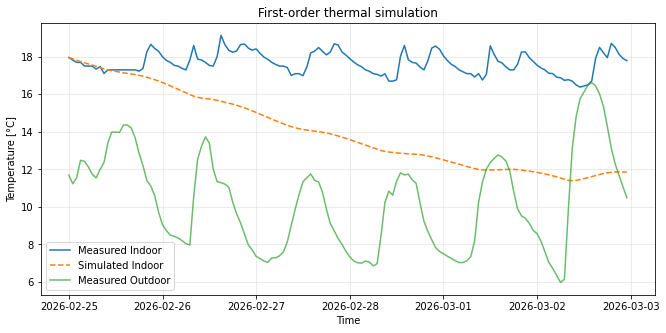

In [6]:
T0 = df_sim[column_in].iloc[0]
df_sim['Tsim_v1'] = simulate_first_order(T0, df_sim[column_out], k)

plt.figure(figsize=(11, 5))
plt.plot(df_sim.index, df_sim[column_in], label="Measured Indoor")
plt.plot(df_sim.index, df_sim["Tsim_v1"], label="Simulated Indoor", linestyle="--")
plt.plot(df_sim.index, df_sim[column_out], label="Measured Outdoor", alpha=0.7)

plt.title("First-order thermal simulation")
plt.xlabel("Time")
plt.ylabel("Temperature [°C]")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Thermal Simulator v1 - Results

Outdoor temperature (green line) rise during day.
Measured indoor temperature (blue line) rise much higher than Tout can explain.

This probably means: **solar gain and/or internal gain (HVAC)**

In [7]:
# Function to calculate metrics
def compute_metrics(y_true, y_pred):
    mae = np.mean(np.abs(y_true - y_pred))
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    return mae, rmse

In [8]:
mae_v1, rmse_v1 = compute_metrics(df_sim[column_in], df_sim['Tsim_v1'])
print(f"V1 MAE  = {mae_v1:.3f} °C")
print(f"V1 RMSE  = {rmse_v1:.3f} °C")

V1 MAE  = 3.666 °C
V1 RMSE  = 4.170 °C


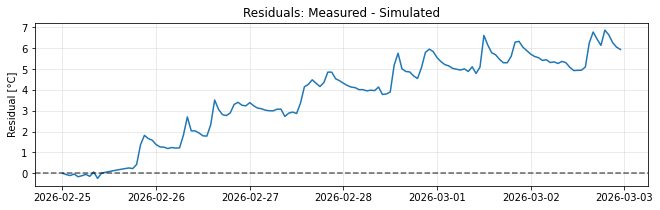

In [9]:
# Plot residuals
df_sim["residual"] = df_sim[column_in] - df_sim["Tsim_v1"]

plt.figure(figsize=(11, 3))
plt.plot(df_sim.index, df_sim["residual"])
plt.axhline(0, color="k", linestyle="--", alpha=0.6)
plt.title("Residuals: Measured - Simulated")
plt.ylabel("Residual [°C]")
plt.grid(True, alpha=0.3)
plt.show()

Presence of internal and/or solar gain is confirmed also by the residuals plot. 
 * During nightime residuals are around 0.
 * During daytime residuals are systematically positive ($T_{measured} \gt T_{simulated}$).

## Thermal Simulator V2
Let's consider a model that takes internal/solar gain into account. Something like:

$T_{t+1} =T_t + (−k(T_t − T_{out})+ g I_{day}(t)) \Delta t $
* I_{day}(t) = 1 if time in range 09:00–16:00
* 0 otherwise
* g in $^oC/h$

g can be estimated by trial-and-error at first.

Simulator v2 will be tested during more days

In [10]:
# Simulator function V2
def simulate_first_order_with_solar(T0, Tout_series, k, dt=1.0, solar_gain=0.2, solar_start="10:00", solar_end="18:00"):
    """
    T_{t+1} = T_t + (-k * (T_t - T_out) + g * I_day) * dt
    """
    Tsim = np.zeros(len(Tout_series), dtype=float)
    Tsim[0] = T0

    # day indicator
    idx = Tout_series.index
    day_mask = ((idx.time >= pd.to_datetime(solar_start).time()) & (idx.time <= pd.to_datetime(solar_end).time())).astype(float)

    for i in range(1, len(Tout_series)):
        T_prev = Tsim[i-1]
        Tout = Tout_series.iloc[i-1]
        solar_term = solar_gain * day_mask[i-1]
        Tsim[i] = T_prev + (-k * (T_prev - Tout) + solar_term) * dt

    return pd.Series(Tsim, index=Tout_series.index, name="Tsim")

In [11]:
df_sim = df_filtered.dropna().copy()
df_sim["Tsim_v2"] = simulate_first_order_with_solar(
    T0,
    df_filtered[column_out],
    k=k,
    dt=dt,
    solar_gain=0.20,      
    solar_start="10:00",
    solar_end="18:00"
)

In [12]:
mae_v2, rmse_v2 = compute_metrics(df_sim[column_in], df_sim["Tsim_v2"])
print(f"V2 MAE: {mae_v2:.3f} °C | RMSE: {rmse_v2:.3f} °C")

V2 MAE: 0.566 °C | RMSE: 0.696 °C


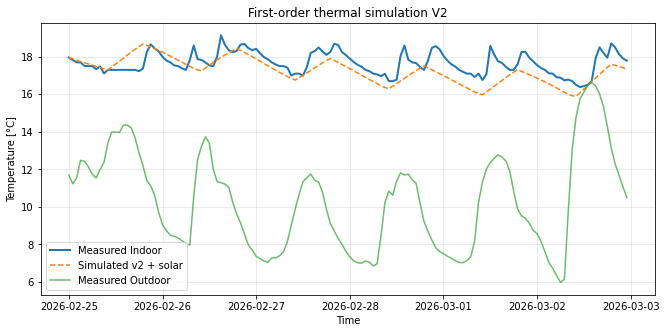

In [13]:
plt.figure(figsize=(11, 5))
plt.plot(df_sim.index, df_sim[column_in], label="Measured Indoor", linewidth=2)
plt.plot(df_sim.index, df_sim["Tsim_v2"], label="Simulated v2 + solar", linestyle="--")
plt.plot(df_sim.index, df_sim[column_out], label="Measured Outdoor", alpha=0.7)
    
plt.title("First-order thermal simulation V2")
plt.xlabel("Time")
plt.ylabel("Temperature [°C]")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Thermal Simulator v2 - Results

Results have significantly improved. Simulator is able to perform much closer to the measured values. MAE and RMSE are low. 

Consquently, **k** parameter has a quite representative value.

## Thermal Simulator - v3

One thing that could improved is the daytime jumps to be more "dynamical" instead of a constant value. So let's define g as:

$g(t) = \alpha \cdot max(T_{out, south}(t) - T_{out, north}(t), 0)$

and the equation of the model (V3) now becomes:

$T_{t+1} = T_t + [-k(T_t - T_{out, north}) + \alpha \cdot max(T_{out, south}(t) - T_{out, north}(t), 0)] \Delta t$

$\alpha$ means:
* gain scaling factor
* turns outdoor difference North-South to "effective heating input" for the northern room

In [14]:
def simulate_first_order_with_dynamic_solar(
    T0, 
    Tout_ref_series,
    Tout_north_series,
    Tout_south_series,
    k,
    alpha,
    dt=1.0
):
    """
    First-order thermal model with dynamic solar proxy:
    
    T_{t+1} = T_t + [-k*(T_t - T_out_ref) + alpha * max(T_out_south - T_out_north, 0)] * dt
    
    Parameters
    ----------
    T0 : float
        Initial indoor temperature
    Tout_ref_series : pd.Series
        Outdoor reference temperature for the room (e.g. north outdoor for north room)
    Tout_north_series : pd.Series
        North outdoor temperature
    Tout_south_series : pd.Series
        South outdoor temperature
    k : float
        Heat loss coefficient [1/h]
    alpha : float
        Dynamic solar gain scaling factor
    dt : float
        Time step in hours
    """
    idx =Tout_ref_series.index
    Tsim = np.zeros(len(idx), dtype=float)
    Tsim[0] = T0

    solar_proxy = np.maximum((Tout_south_series - Tout_north_series).to_numpy(dtype=float), 0.0)

    for i in range(1, len(idx)):
        T_prev = Tsim[i - 1]
        T_out_ref = float(Tout_ref_series.iloc[i - 1])
        solar_term = alpha * solar_proxy[i - 1]

        Tsim[i] = T_prev + (-k * (T_prev - T_out_ref) + solar_term) * dt
    return pd.Series(Tsim, index=idx, name="Tsim_v3")

In [15]:
column_in = "temp_salon_c"
column_out_north = "temp_out_1_b_c"
column_out_south = "temp_out_2_n_c"

In [22]:
df_sim = df_filtered.loc[min_date:max_date, [
    column_in,
    column_out_north,
    column_out_south
]].dropna().copy()

T0 = df_sim[column_in].iloc[0]

df_sim["Tsim_v3"] = simulate_first_order_with_dynamic_solar(
    T0=T0,
    Tout_ref_series=df_sim[column_out_north],
    Tout_north_series=df_sim[column_out_north],
    Tout_south_series=df_sim[column_out_south],
    k=k,
    alpha=0.06,  
    dt=dt
)

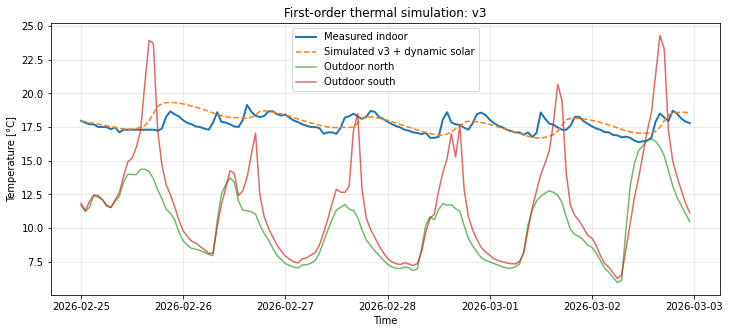

In [23]:
plt.figure(figsize=(12, 5))
plt.plot(df_sim.index, df_sim[column_in], label="Measured indoor", linewidth=2)
plt.plot(df_sim.index, df_sim["Tsim_v3"], label="Simulated v3", linestyle="--")
plt.plot(df_sim.index, df_sim[column_out_north], label="Outdoor north", alpha=0.7)
plt.plot(df_sim.index, df_sim[column_out_south], label="Outdoor south", alpha=0.7)

plt.title("First-order thermal simulation: v3")
plt.xlabel("Time")
plt.ylabel("Temperature [°C]")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [24]:
mae_v3, rmse_v3 = compute_metrics(df_sim[column_in], df_sim["Tsim_v3"])

print(f"V3 MAE: {mae_v3:.3f} °C | RMSE: {rmse_v3:.3f} °C")

V3 MAE: 0.460 °C | RMSE: 0.624 °C


## Thermal Simulator v4

Explore a final enhancement for the thermal simulator.
Additionallly to the warming proxy add also a memory term to account for thermal inertia.

In [19]:
def simulate_first_order_with_memory_solar(
    T0,
    Tout_ref_series,
    k,
    alpha,
    beta=0.85,
    dt=1.0
):
    """
    First-order thermal model with causal outdoor-warming proxy + memory term.

    T_{t+1} = T_t + [-k*(T_t - T_out) + alpha*S_t] * dt
    S_t = beta*S_{t-1} + max(dT_out/dt, 0)
    """

    idx = Tout_ref_series.index
    Tsim = np.zeros(len(idx), dtype=float)
    S = np.zeros(len(idx), dtype=float)
    
    Tsim[0] = T0
    S[0] = 0.0

    Tout = Tout_ref_series.to_numpy(dtype=float)

    for i in range(1, len(idx)):
        # causal warming proxy from past step
        dTout_dt = (Tout[i-1] - Tout[i - 2]) / dt if i >= 2 else 0.0
        warming_proxy = max(dTout_dt, 0.0)
        
        # memory state
        S[i] = beta * S[i - 1] + warming_proxy
        
        T_prev = Tsim[i - 1]
        T_out_ref = Tout[i - 1]
        
        Tsim[i] = T_prev + (-k * (T_prev - T_out_ref) + alpha * S[i]) * dt

    return (pd.Series(Tsim, index=idx, name="Tsim_v4b"),
           pd.Series(S, index=idx, name="solar_memory_state")
    )

In [25]:
T0 = df_sim[column_in].iloc[0]

df_sim["Tsim_v4"], df_sim["solar_state"] = simulate_first_order_with_memory_solar(
    T0=T0,
    Tout_ref_series=df_sim[column_out],
    k=k,
    alpha=0.07, 
    beta=0.83,  
    dt=dt
)

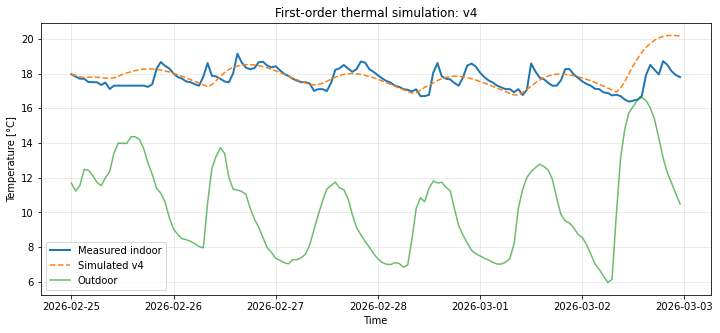

In [27]:
plt.figure(figsize=(12, 5))
plt.plot(df_sim.index, df_sim[column_in], label="Measured indoor", linewidth=2)
plt.plot(df_sim.index, df_sim["Tsim_v4"], label="Simulated v4", linestyle="--")
plt.plot(df_sim.index, df_sim[column_out], label="Outdoor", alpha=0.7)

plt.title("First-order thermal simulation: v4")
plt.xlabel("Time")
plt.ylabel("Temperature [°C]")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [28]:
mae_v4, rmse_v4 = compute_metrics(df_sim[column_in], df_sim["Tsim_v4"])

print(f"V4 MAE: {mae_v4:.3f} °C | RMSE: {rmse_v4:.3f} °C")

V4 MAE: 0.484 °C | RMSE: 0.724 °C
